# Михельсон Владимир 316 Практикум 1

## 1. Описание датасета

In [1]:
!pip install statsmodels

In [2]:
import statsmodels.api as sm # qq-график
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.interpolate import interp1d
import seaborn as sns
from IPython.display import display
from scipy.stats import kstest, anderson, cramervonmises, shapiro
from statsmodels.stats.diagnostic import lilliefors
from outliers import smirnov_grubbs as grubbs # критерий

<p>Для выполнения задания мной был выбран датасет, содержащий данные о качестве красного вина.</p>

In [3]:
file_path = 'winequality-red.csv'
df = pd.read_csv(file_path)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# Краткое описание данных
wine_summary = df.describe()

wine_summary

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
# Распределение оценок качества
quality_counts = df['quality'].value_counts().sort_index()
quality_df = pd.DataFrame({
    'Качество': quality_counts.index,
    'Количество': quality_counts.values,
    'Процент': (quality_counts.values / len(df) * 100)
})

# Корреляция с целевой переменной
correlations = df.corr()['quality'].sort_values(ascending=False) #сортировка по убыванию
corr_df = pd.DataFrame({
    'Признак': correlations.index,
    'Корреляция': correlations.values
})
corr_df = corr_df[corr_df['Признак'] != 'quality'] # удаляем строку с качеством вина

display(quality_df.style
    .set_caption("Распределение оценок качества")
    .format({'Процент': '{:.1f}%'})
    .hide(axis='index')
    .set_properties(**{'text-align': 'center'}))
print('\n')

display(corr_df.style
    .set_caption("Корреляция признаков с качеством")
    .bar(subset=['Корреляция'], align='mid', color=['red', 'green'])
    .hide(axis='index')
    .set_properties(**{'text-align': 'center'}))

Качество,Количество,Процент
3,10,0.6%
4,53,3.3%
5,681,42.6%
6,638,39.9%
7,199,12.4%
8,18,1.1%


Признак,Корреляция
alcohol,0.476166
sulphates,0.251397
citric acid,0.226373
fixed acidity,0.124052
residual sugar,0.013732
free sulfur dioxide,-0.050656
pH,-0.057731
chlorides,-0.128907
density,-0.174919
total sulfur dioxide,-0.185100


## 2.Апроксимизация через ядерные оценки

<h3>Описание данных:</h3>
<p>В работе использованы данные о параметрах вин различного качества. Ключевыми переменными для анализа являются:</p>
<ul>
  <li><b>Качество вина (quality)</b> — соответствие напитка требованиям, установленным нормативными документами.</li>
  <li><b>Крепость (alcohol)</b> — показатель доли безводного этилового спирта в алкогольном напитке.</li>
  <li><b>Летучая кислотность (volatile acidity)</b> —  характеристика напитка, которая ощущается при вдыхании его аромата.</li>
  <li><b>Остаточный сахар (residual sugar)</b> —  натуральные виноградные сахара, которые остаются непреобразованными после ферментации.</li>
</ul>

<h3>Метод анализа:</h3>
<ol>
  <li><b>Гистограммы:</b> Были построены гистограммы для каждого из четырёх параметров, что позволило визуализировать частоту значений в каждом диапазоне. Это базовый метод оценки распределения данных.</li>
  <li><b>Графики плотности распределения (KDE):</b> KDE (ядерная оценка плотности) — это метод сглаживания распределения данных. В отличие от гистограмм, KDE не зависит от жёстко заданных границ интервалов, а использует каждую точку данных для оценки общей плотности распределения. Это позволяет получить более точное представление о форме распределения, особенно если оно имеет сложную структуру с пиками или длинными хвостами.</li>
</ol>

<h3>Корректность применения KDE:</h3>
<p>KDE особенно полезен для анализа непрерывных данных, так как он позволяет сглаживать выбросы и неровности в распределении. В случае с нашими данными применение KDE обосновано, так как мы имеем дело с большим объёмом непрерывных данных, для которых важно визуализировать плотность их распределения.</p>
<p>Для предотвращения искажений анализа были исключены экстремальные значения крепости (выше 95-го процентила), чтобы графики корректно отражали основную массу данных.</p>

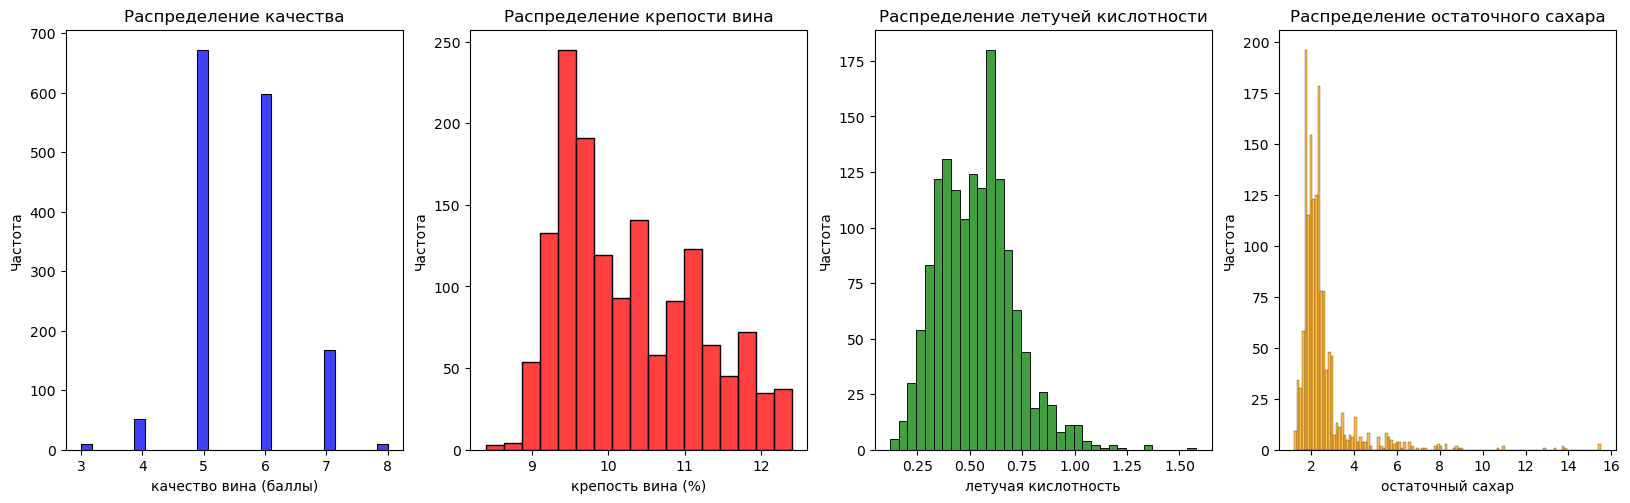

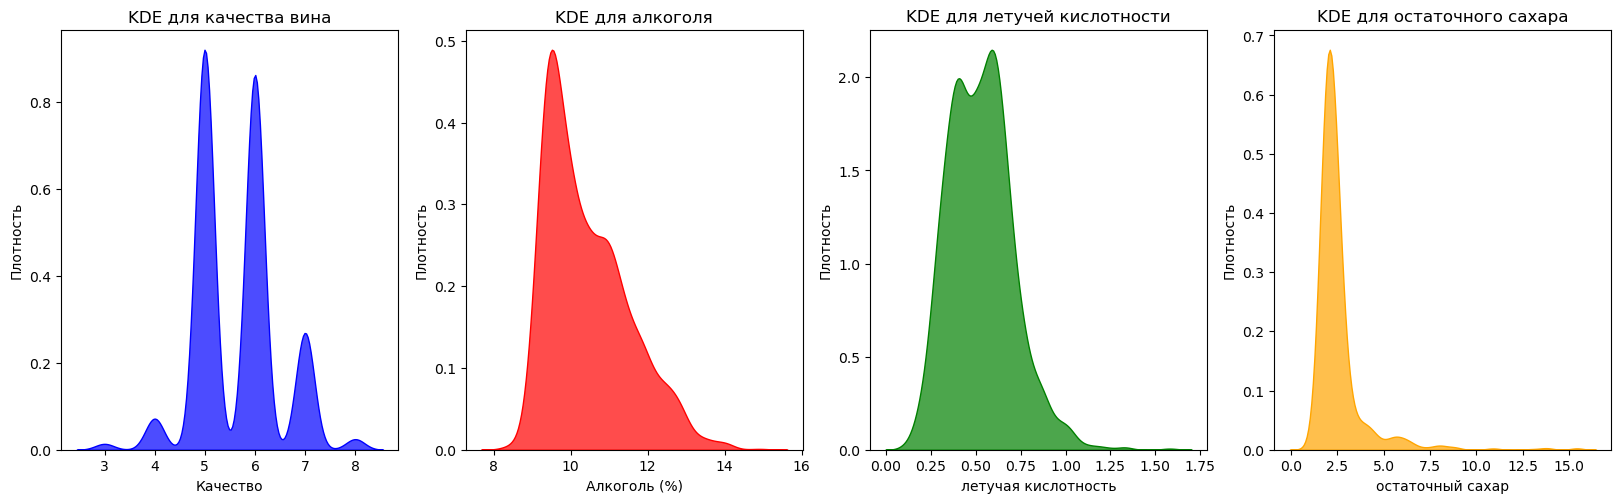

In [6]:
# Фильтрация экстремальных данных  (исключим данные выше 95-го процентила)
filtered_data = df[df['alcohol'] < df['alcohol'].quantile(0.95)]
plt.figure(figsize=(20, 12))

# Гистограммы

plt.subplot(241)
sns.histplot(data=filtered_data, x='quality', color='blue')
plt.title('Распределение качества')
plt.xlabel('качество вина (баллы)')
plt.ylabel('Частота')


plt.subplot(242)
sns.histplot(data=filtered_data, x='alcohol', color='red')
plt.title('Распределение крепости вина')
plt.xlabel('крепость вина (%)')
plt.ylabel('Частота')


plt.subplot(243)
sns.histplot(data=filtered_data, x='volatile acidity', color='green')
plt.title('Распределение летучей кислотности')
plt.xlabel('летучая кислотность')
plt.ylabel('Частота')

plt.subplot(244)
sns.histplot(data=filtered_data, x='residual sugar', color='orange')
plt.title('Распределение остаточного сахара')
plt.xlabel('остаточный сахар')
plt.ylabel('Частота')

# Графики
plt.figure(figsize=(20, 12))
# Ядерная оценка для качества вина
plt.subplot(241)
sns.kdeplot(data=df, x='quality', fill=True, alpha=0.7, color='blue')
plt.title('KDE для качества вина')
plt.xlabel('Качество')
plt.ylabel('Плотность')

# Ядерная оценка для концентрации алкоголя
plt.subplot(242)
sns.kdeplot(data=df, x='alcohol', fill=True, alpha=0.7, color='red')
plt.title('KDE для алкоголя')
plt.xlabel('Алкоголь (%)')
plt.ylabel('Плотность')


# Ядерная оценка для летучей кислотности
plt.subplot(243)
sns.kdeplot(data=df, x='volatile acidity', fill=True, alpha=0.7, color='green')
plt.title('KDE для летучей кислотности')
plt.xlabel('летучая кислотность')
plt.ylabel('Плотность')

# Ядерная оценка для остаточного сахара
plt.subplot(244)
sns.kdeplot(data=df, x='residual sugar', fill=True, alpha=0.7, color='orange')
plt.title('KDE для остаточного сахара')
plt.xlabel('остаточный сахар')
plt.ylabel('Плотность')

plt.show()

<h2>Выводы по данным распределения вина</h2>

<h3>Качество:</h3>
<ul>
  <li><b>Гистограмма:</b> Распределение качества вина расположено по центру, что указывает на преобладание вин среднего качества в выборке. Большая часть часть вин имеет качество 5 и 6.</li>
  <li><b>KDE:</b> Плавная кривая плотности подтверждает, что основная часть вин имеет качество в диапазоне от 5 до 7.</li>
</ul>

<h3>Содержание алкоголя (%):</h3>
<ul>
  <li><b>Гистограмма:</b> Распределение крепости вина имеет форму, схожую с нормальным, с некоторым смещением влево. Это означает, что большинство dby имеют умеренные значения крепости (около 9-12 %).</li>
  <li><b>KDE:</b> График плотности показывает аналогичное поведение: наибольшая плотность наблюдается в диапазоне 10–12 %, после чего кривая резко спадает как в меньшие, так и в большие значения. Это свидетельствует о том, что более крепкие и слабоалкогольные вина встречаются реже.</li>
</ul>

<h3>Летучая кислотность(г/л):</h3>
<ul>
  <li><b>Гистограмма:</b> Распределение летучей кислотности , также похоже на нормальное, с более сильным смещением влево . В выборке преобладают вина с низкими показателями остаточного сахара (2–5). Такие значения типичны для сухих вин.</li>
  <li><b>KDE:</b> График плотности распределения подтверждает высокую концентрацию вин с низкой и средней летучей кислотностью.</li>
</ul>

<h3>Остаточный сахар (г):</h3>
<ul>
  <li><b>Гистограмма:</b> Распределение остаточного сахара,похоже на логарифмически нормальное . В выборке преобладают вина с низкими значениями остаточного сахара. Такие значения характерны для сухих вин.</li>
  <li><b>KDE:</b> Плавная кривая плотности демонстрирует, что большая часть вин содержит от 2 до 5 грамм остаточного сахара.</li>
</ul>

<h3>Общие выводы:</h3>
<ul>
  <li>Большая часть вин имеет высокое качество, а также среднюю крепость, что типично для красных сухих вин.</li>
  <li>Основная масса вин в выборке имеет среднее содержание летучей кислотности и низкое сожержание отсаточного сахара что характерно для качественных вин.</li>
</ul>


## 3.Анализ данных

<h2>Исследование связи между качеством вина и его крепостью (%)</h2>

<p>Проанализируем зависимость между <strong>качеством вина</strong> и его <strong>алкогольной крепостью</strong> (%).</p>

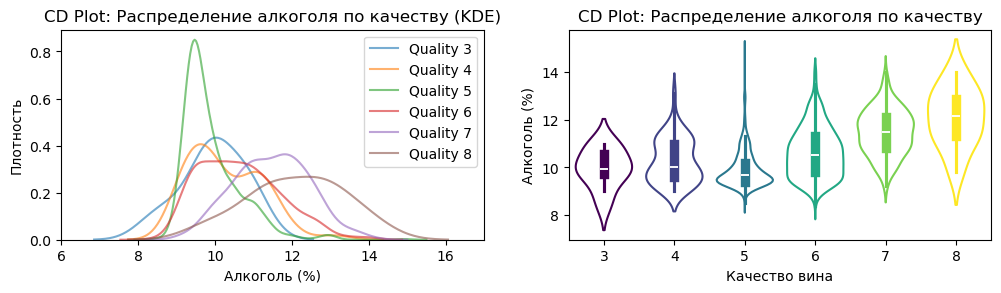

In [7]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
for quality_level in sorted(df['quality'].unique()):
    subset = df[df['quality'] == quality_level]
    density = sns.kdeplot(data=subset, x='alcohol', label=f'Quality {quality_level}', fill=False, alpha=0.6)
plt.title('CD Plot: Распределение алкоголя по качеству (KDE)')
plt.xlabel('Алкоголь (%)')
plt.ylabel('Плотность')
plt.legend()
plt.xlim(6,17)

plt.subplot(2, 2, 2)
sns.violinplot(data=df, x='quality', y='alcohol', hue='quality', palette='viridis', legend=False, fill=False)
plt.title('CD Plot: Распределение алкоголя по качеству')
plt.xlabel('Качество вина')
plt.ylabel('Алкоголь (%)')

plt.show()

<p>Нарисуем 1-й график в большем масштабе<p>

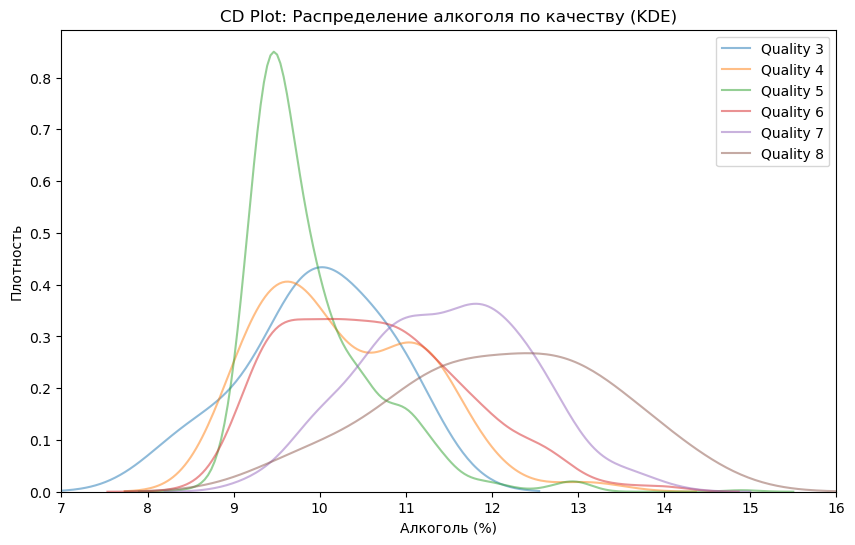

In [8]:
plt.figure(figsize=(10, 6))

for quality_level in sorted(df['quality'].unique()):
    subset = df[df['quality'] == quality_level]
    density = sns.kdeplot(data=subset, x='alcohol', label=f'Quality {quality_level}', fill=False, alpha=0.5)
plt.title('CD Plot: Распределение алкоголя по качеству (KDE)')
plt.xlabel('Алкоголь (%)')
plt.ylabel('Плотность')
plt.xlim(7,16)
plt.legend()
plt.show()

</h3><strong>ВЫВОД:</strong></h3>
<ul>
  <li>Связь между <strong>качеством и крепостью алкоголя — нелинейная</strong>, имеющая форму оптимума (колокола). Качество растет с увеличением алкоголя до определенного предела, после которого дальнейший рост крепости начинает негативно сказываться на сбалансированности и восприятии вина. Большинство вин различного качества имеют крепость 9-14 %.</li>
<ul>

<h2>Исследование связи между остаточный сахором (г) и крепостью вина (%)</h2> <p>Проанализируем зависимость между <strong>остаточный сахором</strong> и <strong>крепостью вина</strong>. Остаточный сахар — это количество сахаров (глюкозы, фруктозы), которые остались в вине после завершения брожения.</p>

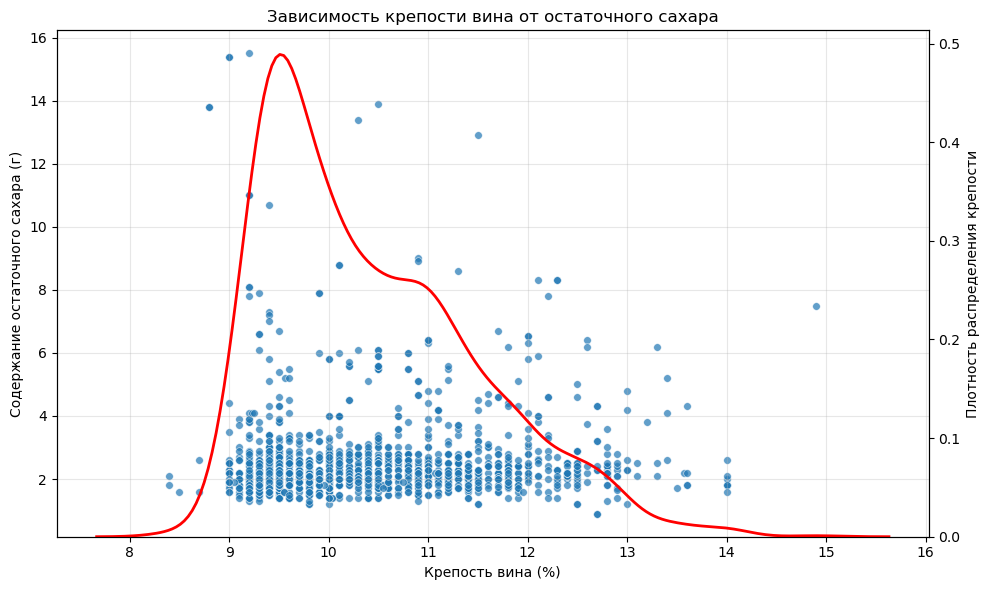

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# График для Алкоголя
sns.scatterplot(x=df['alcohol'], y=df['residual sugar'], s=30, alpha=0.7, ax=ax1)
ax1.set_xlabel('Крепость вина (%)')
ax1.set_ylabel('Содержание остаточного сахара (г)')
ax1.grid(True, alpha=0.3)

# KDE для качества
ax2 = ax1.twinx()
sns.kdeplot(x=df['alcohol'], color='red', ax=ax2, linewidth=2)
ax2.set_ylabel('Плотность распределения крепости')

plt.title('Зависимость крепости вина от остаточного сахара')
plt.tight_layout()
plt.show()

<h3>Вывод</h3> <p>На графике видна слабая связь между <strong>крепостью вина</strong>(%) и <strong>содержанием остаточного сахара</strong> (г). Это следует из того что крепость определяется исходной сахаристостью винограда, а "сухость" (низкий остаточный сахар) — полным завершением брожения. Эти два параметра становятся независимыми на финальной стадии приготовления вина.</p>

<h2>Связь между качеством вина и летучей кислотностью</h2> 
<p>Проанализируем зависимость между <strong>качеством</strong> и <strong>летучей кислотностью</strong> вина.<p>

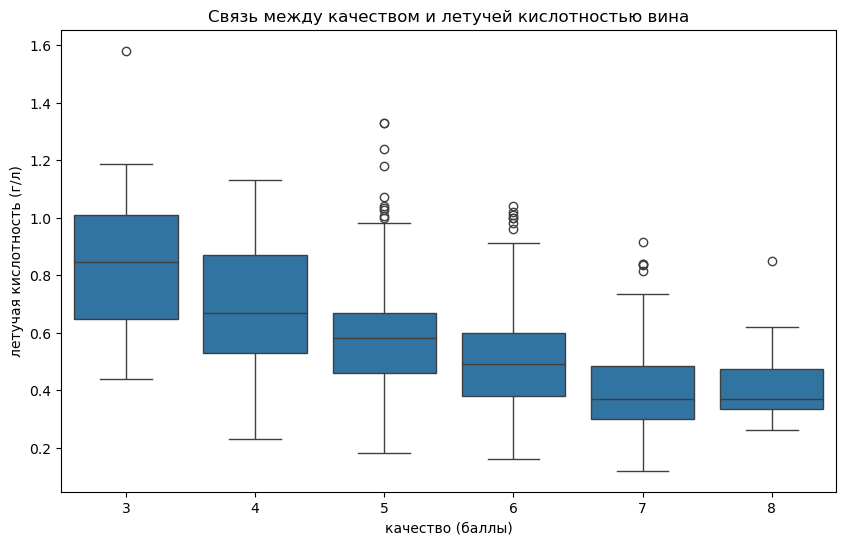

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title('Связь между качеством и летучей кислотностью вина')
plt.xlabel('качество (баллы)')
plt.ylabel('летучая кислотность (г/л)')
plt.show()

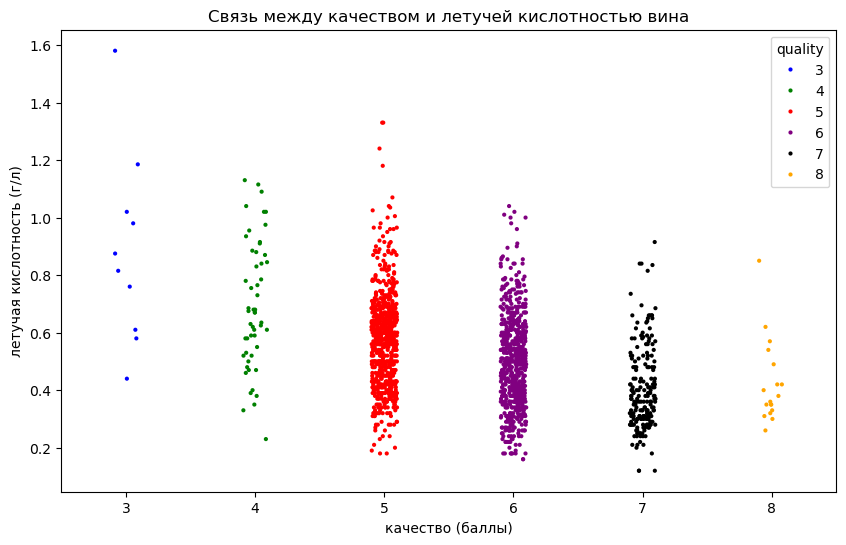

In [11]:
colors = ['blue', 'green', 'red', 'purple','black', 'orange']
plt.figure(figsize=(10, 6))
sns.stripplot(x='quality', y='volatile acidity', data=df, marker='o', palette=colors, s=3, hue = 'quality')
plt.title('Связь между качеством и летучей кислотностью вина')
plt.xlabel('качество (баллы)')
plt.ylabel('летучая кислотность (г/л)')
plt.show()

<h3>Выводы по исследованию связи между качеством и летучей кислотностью вина:</h3>
<ul>
    <li><b>Вина с низким значением качества (3 и 4 балла)</b> имеют более высокое содержание летучей кислотности. Это связано с дешевизной винограда, недостаточно строгим контролем при приготовлении вина.Высокая летучая кислотность - характерный признак для дешевых и не очень качественных вин.</li>
    <li>С увеличением качества вина <b>средняя летучая кислотность уменьшается</b>. Это объясняется тем, что для качетвенных вин используется сырье высшего качества, а на производствах следят за гигиеной и брожением вина.</li>
    <li>Распределение летучей кислотности по качетсву вин показывает наличие разброса, но <b>основные различия наблюдаются между крайними группами</b> (3 — низкое качество и 8 — высокое качество).</li>
</ul>


## 4.Проверка данных на выбросы с использованием тестов Граббса и Q-теста Диксона

<p>Используем два статистических метода: <strong>теста Граббса</strong> и <strong>Q-тест Диксона</strong>. Эти методы направлены на выявление и устранение выбросов — наблюдений, которые значительно отличаются от основной массы данных и могут искажать результаты анализа.</p>

<h3>Тест Граббса</h3>

<p><strong>Тест Граббса</strong> (Grubbs' test), также известный как экстремальный тест, представляет собой мощный метод для обнаружения выбросов в одномерных данных. Этот тест направлен на проверку гипотезы о том, что наиболее экстремальное значение в выборке является выбросом, предполагая, что данные следуют нормальному распределению.</p>

<p>Гипотезы теста Граббса формулируются следующим образом:</p>
<ul>
    <li><strong>Нулевая гипотеза (H<sub>0</sub>):</strong> Все наблюдения принадлежат одной и той же генеральной совокупности, выбросов нет.</li>
    <li><strong>Альтернативная гипотеза (H<sub>1</sub>):</strong> Одно из наблюдений является выбросом.</li>
</ul>

<p>Тест вычисляет статистику Граббса (G), которая определяется по формуле:</p>

$$
G = \frac{\max{|x_i - \bar{x}|}}{s}
$$

<p>где:</p>
<ul>
    <li><em>x<sub>i</sub></em> - подозрительное значение, которое проверяется на выброс;</li>
    <li> $\bar{x}$ - среднее арифметическое выборки;</li>
    <li><em>s</em> - стандартное отклонение выборки.</li>
</ul>

<p>Если рассчитанное значение статистики Граббса превышает критическое значение для данного уровня значимости, то наблюдение считается выбросом. Этот тест особенно эффективен для небольших и средних выборок, когда требуется выявить одиночный выброс.</p>

<h3>Q-тест Диксона</h3>

<p><strong>Q-тест Диксона</strong> (Dixon's Q test) - это непараметрический тест, который применяется для обнаружения выбросов в небольших выборках (обычно менее 30 наблюдений). Метод направлен на выявление экстремальных значений, как максимальных, так и минимальных, и проверяет их на принадлежность к генеральной совокупности.</p>

<p>Для проведения теста вычисляется коэффициент <strong>Q</strong>, который рассчитывается следующим образом:</p>

$$
Q = \frac{x_{ext} - x_{n}}{x_{max} - x_{min}}
$$

<p>где:</p>
<ul>
    <li><em>x<sub>ext</sub></em> — подозрительное экстремальное значение (минимальное или максимальное);</li>
    <li><em>x<sub>n</sub></em> — ближайшее соседнее значение к подозрительному экстремальному значению;</li>
    <li><em>x<sub>max</sub></em> и <em>x<sub>min</sub></em> — максимальное и минимальное значения выборки соответственно.</li>
</ul>

<p>Если рассчитанное значение Q превышает критическое значение для выбранного уровня значимости, то подозрительное значение считается выбросом. Важно отметить, что Q-тест Диксона особенно полезен для анализа малых выборок и может применяться даже в случаях, когда выборка не строго нормальна.</p>

<h3>Обоснование выбора летучей кислотности</h3>

<p>Для анализа выбрана величина <strong>летучей кислотности (г/л)</strong>, поскольку предварительное исследование показало, что её распределение наиболее близко к нормальному среди всех параметров в наборе данных. Это важное условие для корректного применения как теста Граббса, так и Q-теста Диксона, так как оба метода предполагают нормальное распределение данных.</p>

<p>Проверка данных на наличие выбросов с использованием данных методов позволяет повысить точность анализа, обеспечивая чистоту данных и предотвращая возможные искажения, вызванные экстремальными значениями.</p>


In [12]:
# Преобразуем столбец в numpy массив
volatile_acidity_values = df['volatile acidity'].values

# alpha - вероятность отвергнуть верную гипотезу (ошибка первого рода)
min_outliers = grubbs.min_test_outliers(volatile_acidity_values, alpha=0.05)
max_outliers = grubbs.max_test_outliers(volatile_acidity_values, alpha=0.05)

# Находим строки с этими значениями
all_outliers = list(min_outliers) + list(max_outliers)
outliers = df[df['volatile acidity'].isin(all_outliers)]
outliers

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
126,8.2,1.33,0.00,1.7,0.081,3.0,12.0,0.99640,3.53,0.49,10.9,5
127,8.1,1.33,0.00,1.8,0.082,3.0,12.0,0.99640,3.54,0.48,10.9,5
672,9.8,1.24,0.34,2.0,0.079,32.0,151.0,0.99800,3.15,0.53,9.5,5
1299,7.6,1.58,0.00,2.1,0.137,5.0,9.0,0.99476,3.50,0.40,10.9,3


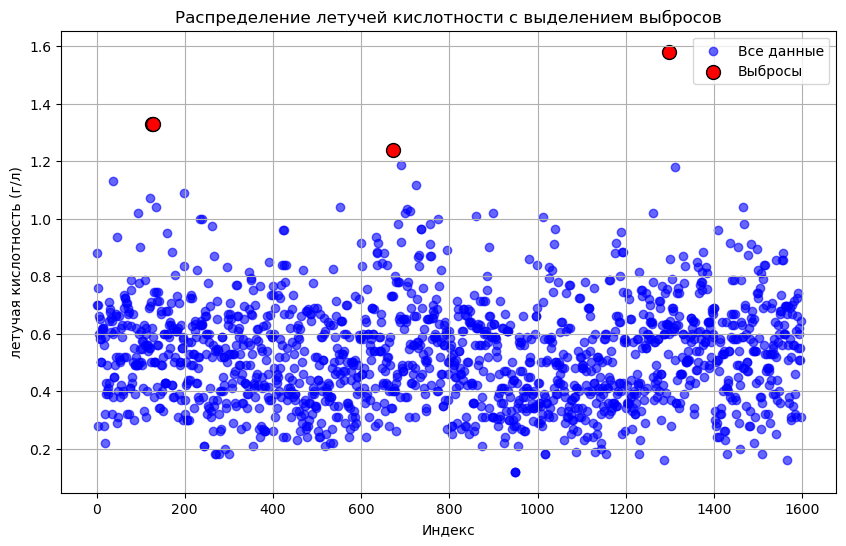

In [13]:
outliers = df.loc[[126, 127, 672, 1299], ['volatile acidity']]

plt.figure(figsize=(10, 6))
plt.scatter(df.index, df['volatile acidity'], label='Все данные', color='blue', alpha=0.6)
plt.scatter(outliers.index, outliers['volatile acidity'], label='Выбросы', color='red', s=100, edgecolor='black')
plt.title('Распределение летучей кислотности с выделением выбросов')
plt.xlabel('Индекс')
plt.ylabel('летучая кислотность (г/л)')
plt.legend()
plt.grid(True)
plt.show()

<h2>Вывод по результатам применения теста Граббса</h2>

<p>В результате применения теста Граббса к распределению летучей кислотности были выявлены следующие наблюдения, которые можно считать выбросами:</p>

<table border="1" cellpadding="5" cellspacing="0">
  <tr>
    <th>Номер объекта</th>
    <th>Летучая кислотность (г/м)</th>
    <th>качество</th>
    <th>Содержание алкоголя (%)</th>
    <th>Остаточный сахар(г)</th>
  </tr>
  <tr>
    <td>126</td>
    <td>1.33</td>
    <td>5</td>
    <td>10.9</td>
    <td>1.7</td>
  </tr>
  <tr>
    <td>127</td>
    <td>1.33</td>
    <td>5</td>
    <td>10.9</td>
    <td>1.8</td>
  </tr>
  <tr>
    <td>672</td>
    <td>1.24</td>
    <td>5</td>
    <td>9.5</td>
    <td>2.0</td>
  </tr>
  <tr>
    <td>1299</td>
    <td>1.58</td>
    <td>3</td>
    <td>10.9</td>
    <td>2.1</td>
  </tr>
</table>

<p>Эти объекты имеют значения летучей кислотности вина, которые значительно отличаются от среднего по выборке, что указывает на их статус как выбросов.</p>

<p>Анализ показал, что среди выбросов находятся только вина с высокой летучей кислотностью. И все эти вина имеют качество не выше 5</p>

<h2> Q-тест Диксона </h2>


In [14]:
def dixon_test(df):
    n = len(df)
    sorted_data = sorted(df)
    q_min = (sorted_data[1] - sorted_data[0]) / (sorted_data[-1] - sorted_data[0])
    q_max = (sorted_data[-1] - sorted_data[-2]) / (sorted_data[-1] - sorted_data[0])

    # Критическое значение для alpha = 0.05
    q_crit = 0.260

    min_outlier = q_min > q_crit
    max_outlier = q_max > q_crit

    return min_outlier, max_outlier
unique_volatile_acidity_values = df['volatile acidity'].unique()

smallest_unique_volatile_acidity = sorted(unique_volatile_acidity_values)[:30] #30 наименьших значений
largest_unique_volatile_acidity = sorted(unique_volatile_acidity_values)[-30:] #30 наибольших значений

min_outlier_max_volatile_acidity_filtered, max_outlier_max_volatile_acidity_filtered = dixon_test(largest_unique_volatile_acidity)
min_outlier_min_volatile_acidity_filtered, max_outlier_min_volatile_acidity_filtered = dixon_test(smallest_unique_volatile_acidity)

print(min_outlier_max_volatile_acidity_filtered, max_outlier_max_volatile_acidity_filtered)
print(min_outlier_min_volatile_acidity_filtered, max_outlier_min_volatile_acidity_filtered)

False True
False False


<h2> Расшифровка результатов Q-теста </h2>

<p>Среди 30 наименьших значений летучей кислотности выбросов нет (Два нижних False). Среди 30 наибольших значений летучей кислотности выброс есть. <strong>Самый большой элемент в этой группе ЯВЛЯЕТСЯ выбросом</strong></p>

In [15]:
largest_values = sorted(unique_volatile_acidity_values)[-30:]
print("Выброс (наибольшее):", largest_values[-1])

Выброс (наибольшее): 1.58


In [16]:
largest_unique_volatile_acidity = sorted(unique_volatile_acidity_values)[-31:-1]
min_outlier_max_volatile_acidity_filtered, max_outlier_max_volatile_acidity_filtered = dixon_test(largest_unique_volatile_acidity)
print(min_outlier_max_volatile_acidity_filtered, max_outlier_max_volatile_acidity_filtered)

False False


<p>Если рассмотреть с 31 по 2 (Исключая наибольшее , которое оказалось выбросом) вина с наибольшей концентрацией летучей кислотности, то Q-тест наличие выбросов не показывает</p>

## 5.Методы восстановления пропусков в данных

<p>Восстановление пропущенных данных — важная задача при обработке данных. Для этого могут использоваться различные подходы, имеющие различные преимущества и недостатки. В данном примере мы рассмотрим три основных метода заполнения пропусков: с использованием среднего значения, линейной интерполяции и медианы.</p>

<h3>1. Заполнение среднего значения</h3>
<p>Метод заполнения пропусков средним значением является одним из самых простых и распространённых. В этом подходе пропущенные значения заменяются средним значением всех доступных данных в столбце. Это эффективно для случаев, когда данные распределены равномерно и пропуски незначительны, но может приводить к значительным ошибкам, если данные содержат выбросы или сильно варьируются.</p>

<h3>2. Линейная интерполяция</h3>
<p>Линейная интерполяция заполняет пропуски, предполагая, что значения между известными точками изменяются линейно. Для каждого пропуска находятся ближайшие значения до и после пропуска, и на их основе строится прямая линия. Пропущенное значение рассчитывается как точка на этой линии. Этот метод подходит для данных, которые изменяются плавно и без резких скачков.</p>

<h3>3. Заполнение медианным значением</h3>
<p>Медианное значение часто используется для заполнения пропусков, когда данные содержат выбросы или асимметричны. В этом методе пропуски заполняются значением, которое находится посередине всех имеющихся данных (медиана). Это позволяет избежать влияния крайних значений на восстановленные данные, делая этот метод более устойчивым по сравнению со средним значением.</p>

<p>Каждый из этих методов необходимо применять в разных ситуациях, и выбор подхода зависит от характера данных и количества пропусков. Искуственно создадим пропуски в данных о крепости вина и сравним результаты восстановления пропусков с использованием всех трёх методов и оценим их точность.</p>


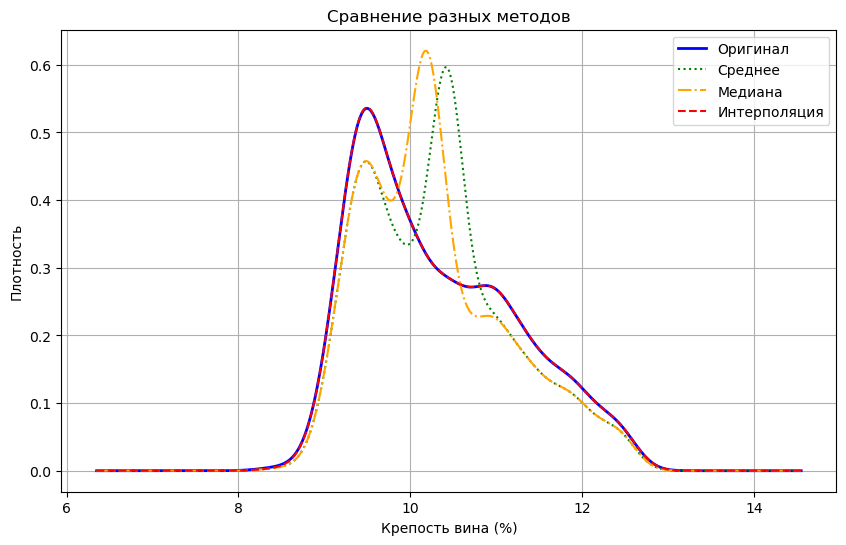

In [17]:
alcohol_data = df['alcohol'].sort_values().reset_index(drop=True) #Сортируем наш столбец по возрастанию

# Удаляем каждый 6й эллемент
alcohol_data_with_nans = alcohol_data.copy()
alcohol_data_with_nans[::6] = None

# Заполняем пропуски
mean_filled = alcohol_data_with_nans.fillna(alcohol_data_with_nans.mean())
median_filled = alcohol_data_with_nans.fillna(alcohol_data_with_nans.median())
interpolated_filled = alcohol_data_with_nans.interpolate(method='linear')

#Визуализируем данные с помощью KDE
quantile_95 = alcohol_data.quantile(0.95)
alcohol_data_95 = alcohol_data[alcohol_data <= quantile_95]
mean_filled_95 = mean_filled[mean_filled <= quantile_95]
median_filled_95 = median_filled[median_filled <= quantile_95]
interpolated_filled_95 = interpolated_filled[interpolated_filled <= quantile_95]

plt.figure(figsize=(10, 6))
alcohol_data_95.plot.kde(label='Оригинал', linestyle='-', linewidth=2,color = 'blue')
mean_filled_95.plot.kde(label='Среднее', linestyle=':', color = 'green')
median_filled_95.plot.kde(label='Медиана', linestyle='-.',color = 'orange')
interpolated_filled_95.plot.kde(label='Интерполяция', linestyle='--',color = 'red')

plt.title('Сравнение разных методов')
plt.xlabel('Крепость вина (%)')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
#считаем ошибку
nan_indices = alcohol_data_with_nans[alcohol_data_with_nans.isna()].index #индексы с пропусками
mean_error = (mean_filled[nan_indices] - alcohol_data[nan_indices]).abs().mean()
median_error = (median_filled[nan_indices] - alcohol_data[nan_indices]).abs().mean()
interpolation_error = (interpolated_filled[nan_indices] - alcohol_data[nan_indices]).abs().mean()

print(mean_error,' , ', median_error,' , ', interpolation_error)


0.8790838591400391  ,  0.8606117353308365  ,  0.0041353383458646335


Средняя ошибка при заполнении пропусков: <ul> <li>Среднее значение: <strong>0.879</strong></li> <li>Медиана: <strong>0.86</strong></li> <li>Линейная интерполяция: <strong>0.0041</strong> (наиболее точный метод)</li> </ul> </li> </ul> <p>Из полученных результатов видно, что линейная интерполяция дает наименьшую среднюю ошибку, что свидетельствует о её высокой точности в случае частых пропусков в наборе данных.

Заметим, что при более редких пропусках метод среднего значения и интегрполяции будет приближаться к реальной плотности распределения данных</p>

## 6.Анализ данных с помощью графиков квантилей, метода огибающих и эмпирической функции распределения стандартных процедур проверки гипотез о нормальности (сгенерированные данные из нормального распределения)

In [19]:
'''
np.random.normal(loc, scale, size)
loc - среднее значение (центр распределения)
scale - стандартное отклонение (разброс данных)
size - размер выходного массива
'''

data1 = np.random.normal(0, 1, size=100)
data2 = np.random.normal(0, 2, size=100)
data3 = np.random.normal(0, 1, size=2000)
data4 = np.random.normal(2, 1, size=2000)

### Эмпирические функции распределения

<h4>Описание метода эмпирической функции распределения</h4>

<p><strong>Эмпирическая функция распределения</strong> - это непараметрическая оценка теоретической функции распределения, построенная непосредственно по выборке.

Для выборки Х1, Х2 ... Хn эмпирическая функция распределения F<sub>n</sub>(X) строится по формуле:$$F_n(X) = \frac{1}{n} \sum_{i=1}^{n} I_{X_i \leq X}$$

Затем эмпирическая функция распределения сравнивается с теоретической и чем ближе F<sub>n</sub>(X) к F(X), тем ближе распределение наших данных к теоретическому распределению. 
</p>


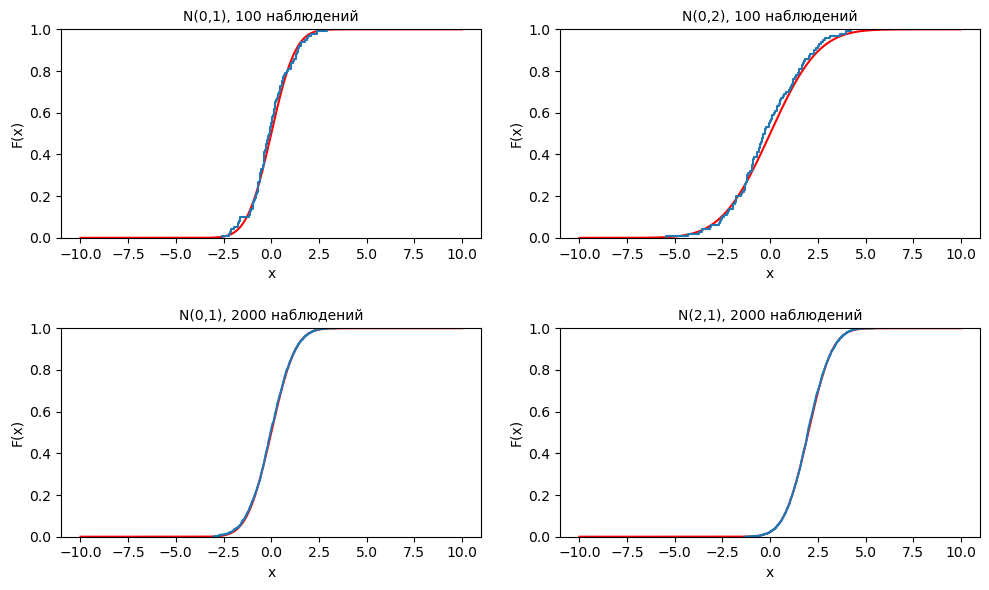

In [20]:
fig = plt.figure(figsize=(10,6))
x = np.linspace(-10, 10, 1000)

ax1 = plt.subplot(221)
plt.plot(x, stats.norm.cdf(x), color='red') # теоретическая функция распределения
sns.ecdfplot(data=data1) #эмпирическая функция распределения
plt.xticks(fontsize=10)
plt.xlabel('x', fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel('F(x)', fontsize=10)
ax1.set_title('N(0,1), 100 наблюдений', fontsize=10)

ax2 = plt.subplot(222, sharex=ax1, sharey=ax1)
plt.plot(x, stats.norm.cdf(x, 0, 2), color='red')
sns.ecdfplot(data=data2)
plt.xticks(fontsize=10)
plt.xlabel('x', fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel('F(x)', fontsize=10)
ax2.set_title('N(0,2), 100 наблюдений', fontsize=10)

ax3 = plt.subplot(223, sharex=ax1, sharey=ax1)
plt.plot(x, stats.norm.cdf(x), color='red')
sns.ecdfplot(data=data3)
plt.xticks(fontsize=10)
plt.xlabel('x', fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel('F(x)', fontsize=10)
ax3.set_title('N(0,1), 2000 наблюдений', fontsize=10)

ax4 = plt.subplot(224, sharex=ax1, sharey=ax1)
plt.plot(x, stats.norm.cdf(x, 2, 1), color='red')
sns.ecdfplot(data=data4)
plt.xticks(fontsize=10)
plt.xlabel('x', fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel('F(x)', fontsize=10)
ax4.set_title('N(2,1), 2000 наблюдений', fontsize=10)

fig.tight_layout(h_pad=2, w_pad=2)

plt.show()

### Метод квантилей

<h4>Описание метода квантилей</h4>

<p><strong>Метод квантилей</strong> - это статистический подход, основанный на сравнении квантилей двух распределений. Квантиль - это значение, ниже которого попадает определенная доля наблюдений в выборке. Например, медиана - это квантиль 0.5. Зачастую под методм квантилей подразумевается график квантиль-квантиль.

<strong>Q-Q plot </strong> - это графический метод для проверки гипотезы о том, что выборка происходит из определенного теоретического распределения. Способ построения квантиль-квантиль графика таков:
<ul>
    <li>Берутся выборочные квантили данных.</li>
    <li>Рассчитываются теоретические квантили для предполагаемого распределения на тех же вероятностях.</li>
    <li>Каждая точка на графике имеет координаты (теоретический квантиль, выборочный квантиль).</li>
</ul>
Если точки легли примерно на прямую линию (особенно на линию y=x), это сильный признак того, что данные действительно следуют предполагаемому теоретическому распределению.
</p>


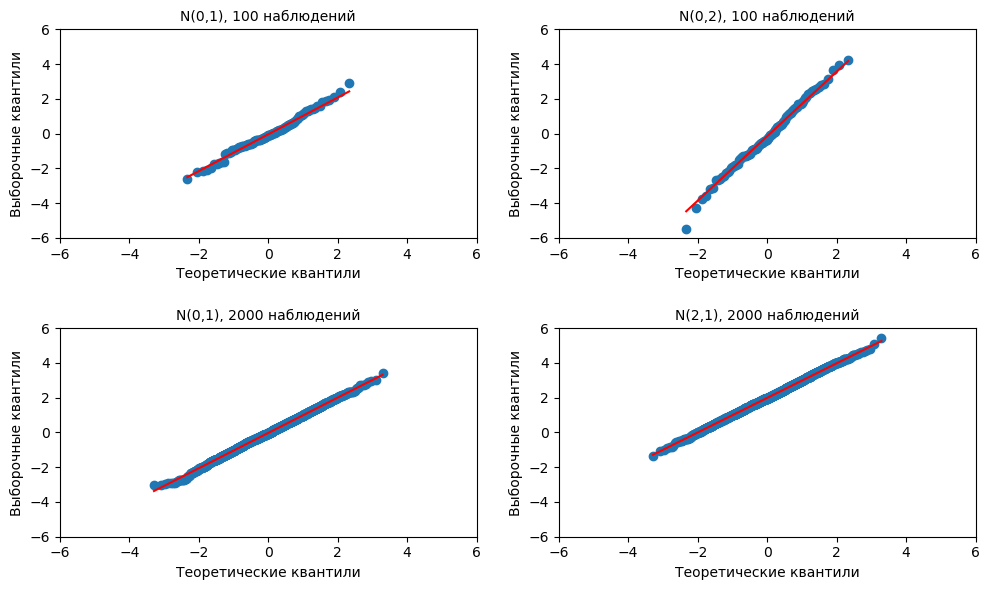

In [21]:
fig = plt.figure(figsize=(10,6))

ax1 = plt.subplot(221)
sm.qqplot(data1, ax=ax1, line='s')
plt.xticks(fontsize=10)
plt.xlabel('Теоретические квантили', fontsize=10)
ax1.set_xlim(-6, 6)
plt.yticks(fontsize=10)
ax1.set_ylim(-6, 6)
plt.ylabel('Выборочные квантили', fontsize=10)
ax1.set_title('N(0,1), 100 наблюдений', fontsize=10)

ax2 = plt.subplot(222, sharex=ax1, sharey=ax1)
sm.qqplot(data2, ax=ax2, line='s')
plt.xticks(fontsize=10)
plt.xlabel('Теоретические квантили', fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel('Выборочные квантили', fontsize=10)
ax2.set_title('N(0,2), 100 наблюдений', fontsize=10)

ax3 = plt.subplot(223, sharex=ax1, sharey=ax1)
sm.qqplot(data3, ax=ax3, line='s')
plt.xticks(fontsize=10)
plt.xlabel('Теоретические квантили', fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel('Выборочные квантили', fontsize=10)
ax3.set_title('N(0,1), 2000 наблюдений', fontsize=10)

ax4 = plt.subplot(224, sharex=ax1, sharey=ax1)
sm.qqplot(data4, ax=ax4, line='s')
plt.xticks(fontsize=10)
plt.xlabel('Теоретические квантили', fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel('Выборочные квантили', fontsize=10)
ax4.set_title('N(2,1), 2000 наблюдений', fontsize=10)

fig.tight_layout(h_pad=2, w_pad=2)

plt.show()

### Метод огибающих

<h4> Описание метода огибающей</h4>

<p><strong>Метод огибающей</strong> - это статистический метод, который позволяет оценить, насколько эмпирическое распределение данных соответствует теоретическому, с помощью построения доверительных границ вокруг ожидаемого соотношения. Алгортитм применения этого метода такой:
<ul>
    <li>Предположим, что данные следуют теоретическому распределению F</li>
    <li>Строим статистику для выборки (например, квантили)</li>
    <li>Найдем доверительные границы</li>
    <li>Сравним реальные данные с этими границами.</li>
</ul>
    
</p>

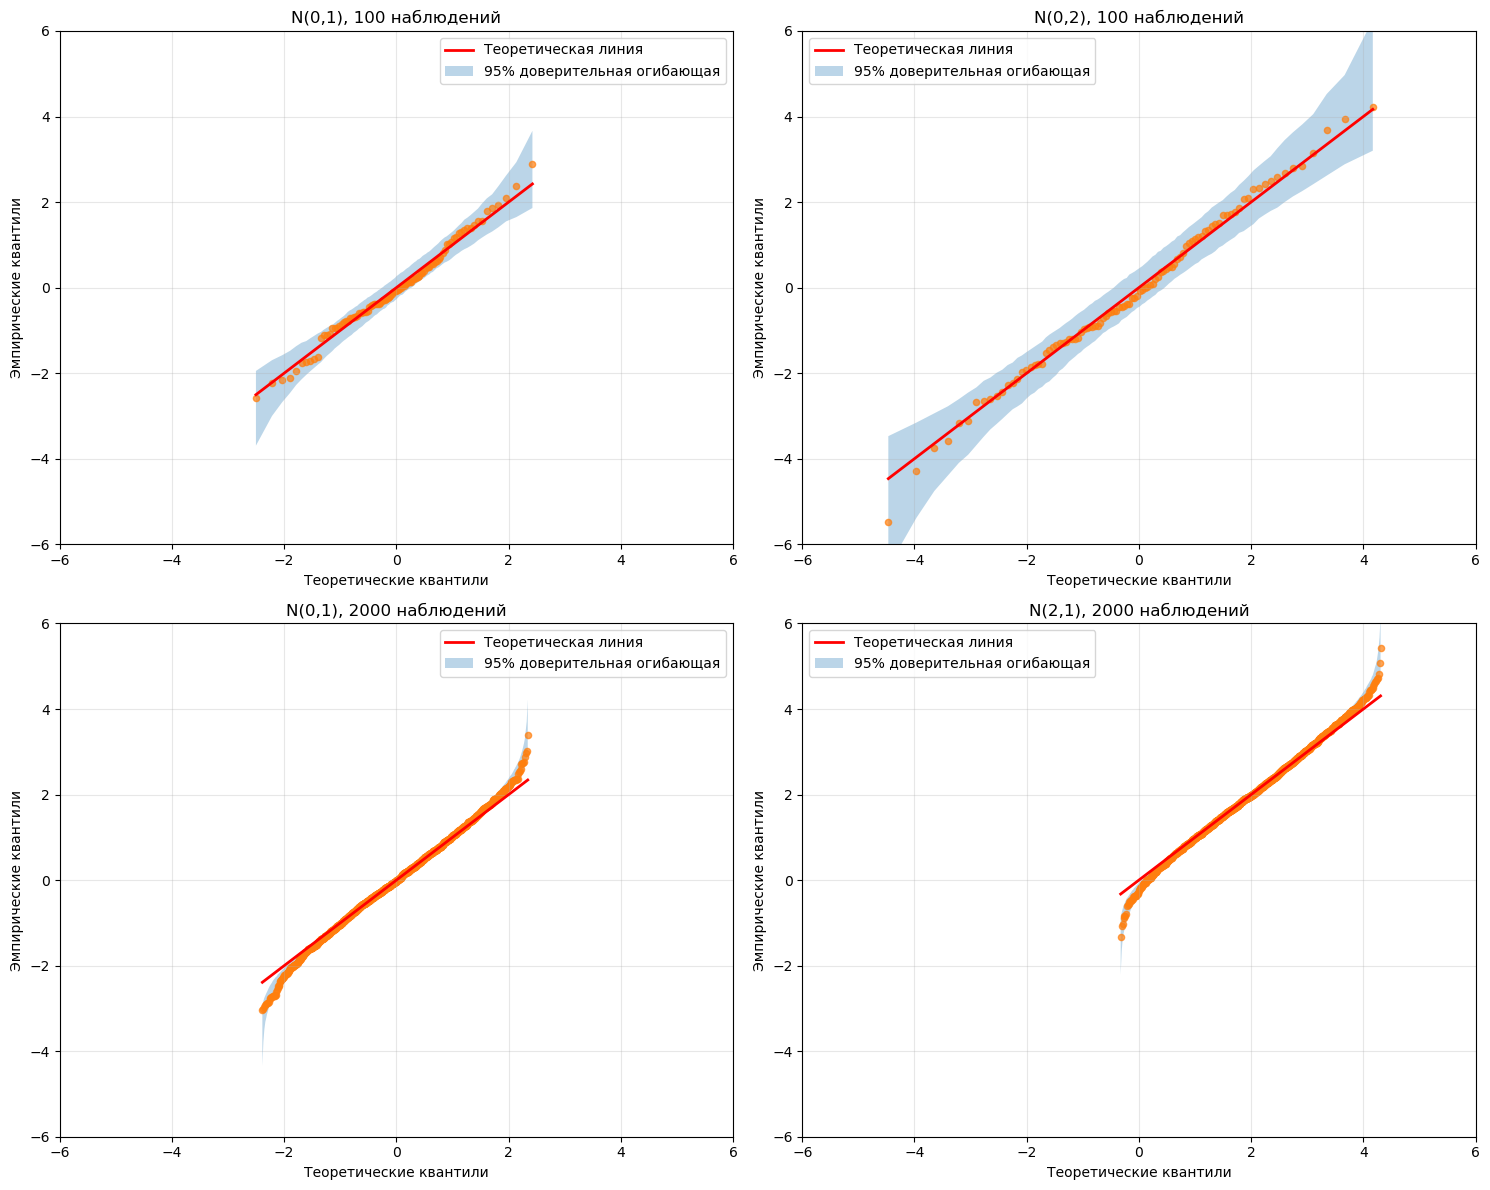

In [22]:
def envelope_method(data, dist='norm', alpha=0.05, n_sim=1000, ax=None, label=''):
    """
    Построение метода огибающей для анализа распределения
    
    Parameters:
    data - массив данных
    dist - тип распределения ('norm' для нормального)
    alpha - уровень значимости
    n_sim - количество симуляций для построения огибающей
    ax - ось для построения графика
    label - метка для данных
    """
    
    # Сортируем данные
    data_sorted = np.sort(data)
    n = len(data_sorted)
    
    # Теоретические квантили
    # Оцениваем параметры нормального распределения
    mu, sigma = np.mean(data), np.std(data)
    theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, n), mu, sigma)
    
    # Генерируем симуляции для построения огибающей
    envelope_data = []
    
    for _ in range(n_sim):
        # Генерируем данные из теоретического распределения
        sim_data = np.random.normal(mu, sigma, n)        
        sim_sorted = np.sort(sim_data)
        envelope_data.append(sim_sorted)
    
    envelope_data = np.array(envelope_data)
    
    # Вычисляем процентили для огибающей
    lower_bound = np.percentile(envelope_data, alpha/2*100, axis=0)
    upper_bound = np.percentile(envelope_data, (1-alpha/2)*100, axis=0)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(theoretical_quantiles, theoretical_quantiles, 'r-', linewidth=2, label='Теоретическая линия')
    
    ax.fill_between(theoretical_quantiles, lower_bound, upper_bound, alpha=0.3,label=f'{int((1-alpha)*100)}% доверительная огибающая')
    
    ax.scatter(theoretical_quantiles, data_sorted, alpha=0.7, s=20, label=label)

    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    plt.xticks(fontsize=10)
    ax.set_xlabel('Теоретические квантили')
    plt.yticks(fontsize=10)
    ax.set_ylabel('Эмпирические квантили')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return ax

# создаем место для 4-х графиков
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Анализируем каждый набор данных
envelope_method(data1, ax=axes[0,0])
axes[0,0].set_title('N(0,1), 100 наблюдений')

envelope_method(data2, ax=axes[0,1])
axes[0,1].set_title('N(0,2), 100 наблюдений')

envelope_method(data3, ax=axes[1,0])
axes[1,0].set_title('N(0,1), 2000 наблюдений')

envelope_method(data4, ax=axes[1,1])
axes[1,1].set_title('N(2,1), 2000 наблюдений')

plt.tight_layout()
plt.show()

### Критерии Колмогорова-Смирнова, Шапиро-Уилка, Андерсона-Дарлинга, Крамера фон Мизеса, Колмогорова-Смирнова в модификации Лиллиефорса и Шапиро-Франсия

<h4>Краткое описание тестов:</h4>

<p><strong>Тест Шапиро-Уилка (и Шапиро-Франсиа)</strong> Рассчитан на небольшие выборки (до 5000 наблюдений). Оценивает нормальность данных, основываясь на линейности Q-Q графика.

<strong>Тест Андерсона-Дарлинга</strong> Использует взвешенные отклонения эмпирической функции распределения от теоретической. Подходит для малых и средних выборок.

<strong>Критерий Крамера-фон Мизеса</strong> Проверяет согласованность эмпирической функции распределения с теоретической, суммируя отклонения. Более чувствителен к отклонениям в середине распределения.

<strong>Тест Колмогорова-Смирнова</strong> Использует максимальное отклонение эмпирической функции распределения от теоретической. Подходит для любого объёма выборки.

<strong>Модификация Лиллиефорса теста Колмогорова-Смирнова</strong> Учитывает отклонения эмпирической функции распределения от нормального распределения, где параметры (среднее и дисперсия) оцениваются из выборки.
</p>

In [23]:
#вывод результатов
def printresults(p_value, name, alpha=0.05):
  print(name)
  print('    pvalue =', p_value)
  print('    Есть ли основания отбросить гипотезу?', 'Да' if (p_value < alpha) else 'Нет')

In [24]:
Data = [data1, data2, data3, data4]
Names = ['N(0,1), 100 наблюдений:', 'N(0,2), 100 наблюдений:', 'N(0,1), 2000 наблюдений:', 'N(2,1), 2000 наблюдений:']

In [25]:
print('\nСмирнов-Колмогоров')
for i in range(len(Data)):
  empty, p_value = kstest(Data[i], 'norm', args=(np.mean(Data[i]), np.std(Data[i])))
  printresults(p_value, Names[i])


print('\nШапиро-Уилк')
for i in range(len(Data)):
  empty, p_value = shapiro(Data[i])
  printresults(p_value, Names[i])

print('\nАндерсон-Дарлинг')
for i in range(len(Data)):
    result = anderson(Data[i], dist='norm')
    statistic = result.statistic # Рассчитанная статистика теста
    critical_value_5_percent = result.critical_values[2]  # Критическое значение для уровня значимости 5%
    p_value = 0.04 if statistic > critical_value_5_percent else 0.06
    printresults(p_value, Names[i])


print('\nКрамер-фон Мизес')
for i in range(len(Data)):
    result = cramervonmises(Data[i], 'norm', args=(np.mean(Data[i]), np.std(Data[i])))
    p_value = result.pvalue
    printresults(p_value, Names[i])

print('\nЛиллиефорс')
for i in range(len(Data)):
    empty, p_value = lilliefors(Data[i], dist='norm')
    printresults(p_value, Names[i])

print('\nШапиро-Франсия')
for i in range(len(Data)):
    empty, p_value = shapiro(Data[i])
    printresults(p_value, Names[i])


Смирнов-Колмогоров
N(0,1), 100 наблюдений:
    pvalue = 0.9134396107754863
    Есть ли основания отбросить гипотезу? Нет
N(0,2), 100 наблюдений:
    pvalue = 0.9517394001851373
    Есть ли основания отбросить гипотезу? Нет
N(0,1), 2000 наблюдений:
    pvalue = 0.6259995379879001
    Есть ли основания отбросить гипотезу? Нет
N(2,1), 2000 наблюдений:
    pvalue = 0.7723548022327398
    Есть ли основания отбросить гипотезу? Нет

Шапиро-Уилк
N(0,1), 100 наблюдений:
    pvalue = 0.6494165431077588
    Есть ли основания отбросить гипотезу? Нет
N(0,2), 100 наблюдений:
    pvalue = 0.9722819532606709
    Есть ли основания отбросить гипотезу? Нет
N(0,1), 2000 наблюдений:
    pvalue = 0.4171202672596397
    Есть ли основания отбросить гипотезу? Нет
N(2,1), 2000 наблюдений:
    pvalue = 0.9337025946812494
    Есть ли основания отбросить гипотезу? Нет

Андерсон-Дарлинг
N(0,1), 100 наблюдений:
    pvalue = 0.06
    Есть ли основания отбросить гипотезу? Нет
N(0,2), 100 наблюдений:
    pvalue = 0.06

<p>Все тесты, показали, что данные, сгенерированные по нормальному распределению, имеют нормальное распределение</p>

## 7.Проверка нормальности данных датасета

### Эмпирические функции распределения

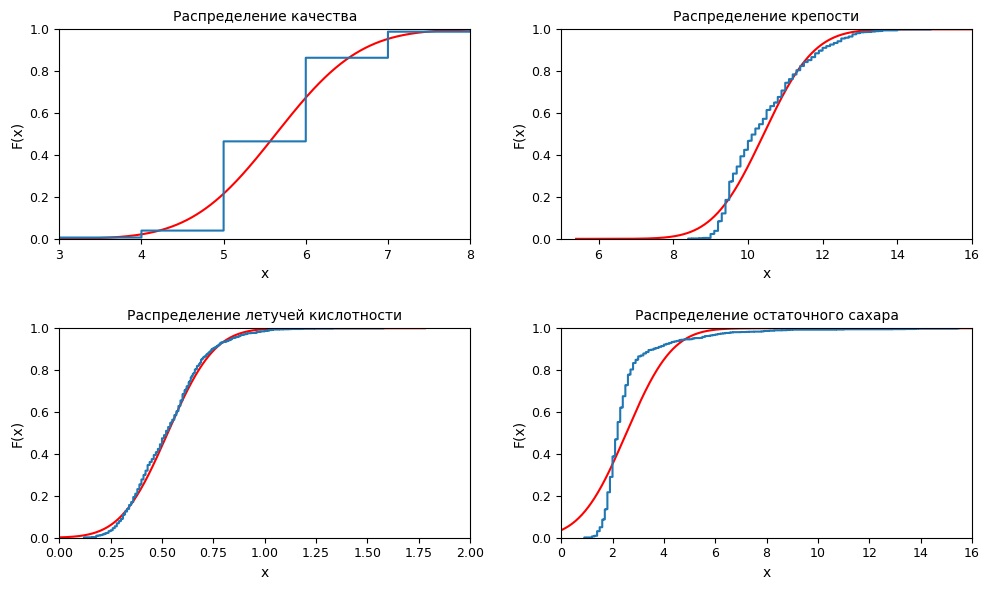

In [26]:
fig = plt.figure(figsize=(10, 6))
x_quality = np.linspace(df['quality'].min() - 1, df['quality'].max() + 1, 1000)
x_alcohol = np.linspace(df['alcohol'].min() - 3, df['alcohol'].max() + 3, 1000)
x_volatile_acidity = np.linspace(df['volatile acidity'].min() - 0.2, df['volatile acidity'].max() + 0.2, 1000)
x_residual_sugar = np.linspace(df['residual sugar'].min()-3, df['residual sugar'].max()+3, 1000)

ax1 = plt.subplot(221)
plt.plot(x_quality, stats.norm.cdf(x_quality, loc=df['quality'].mean(), scale=df['quality'].std()), color='red')
sns.ecdfplot(data=df['quality'])
plt.xlim(df['quality'].min(), df['quality'].max())
plt.xticks(fontsize=9)
plt.xlabel('x', fontsize=10)
plt.yticks(fontsize=9)
plt.ylabel('F(x)', fontsize=10)
ax1.set_title('Распределение качества', fontsize=10)

ax2 = plt.subplot(222)
plt.plot(x_alcohol, stats.norm.cdf(x_alcohol, loc=df['alcohol'].mean(), scale=df['alcohol'].std()), color='red')
sns.ecdfplot(data=df['alcohol'])
plt.xlim(5, 16)
plt.xticks(fontsize=9)
plt.xlabel('x', fontsize=10)
plt.yticks(fontsize=9)
plt.ylabel('F(x)', fontsize=10)
ax2.set_title('Распределение крепости', fontsize=10)

ax3 = plt.subplot(223)
plt.plot(x_volatile_acidity, stats.norm.cdf(x_volatile_acidity, loc=df['volatile acidity'].mean(), scale=df['volatile acidity'].std()), color='red')
sns.ecdfplot(data=df['volatile acidity'])
plt.xlim(0, 2)
plt.xticks(fontsize=9)
plt.xlabel('x', fontsize=10)
plt.yticks(fontsize=9)
plt.ylabel('F(x)', fontsize=10)
ax3.set_title('Распределение летучей кислотности', fontsize=10)

ax4 = plt.subplot(224)
plt.plot(x_residual_sugar, stats.norm.cdf(x_residual_sugar, loc=df['residual sugar'].mean(), scale=df['residual sugar'].std()), color='red')
sns.ecdfplot(data=df['residual sugar'])
plt.xlim(0, 16)
plt.xticks(fontsize=9)
plt.xlabel('x', fontsize=10)
plt.yticks(fontsize=9)
plt.ylabel('F(x)', fontsize=10)
ax4.set_title('Распределение остаточного сахара', fontsize=10)

fig.tight_layout(h_pad=2, w_pad=2)

plt.show()

### Метод квантилей

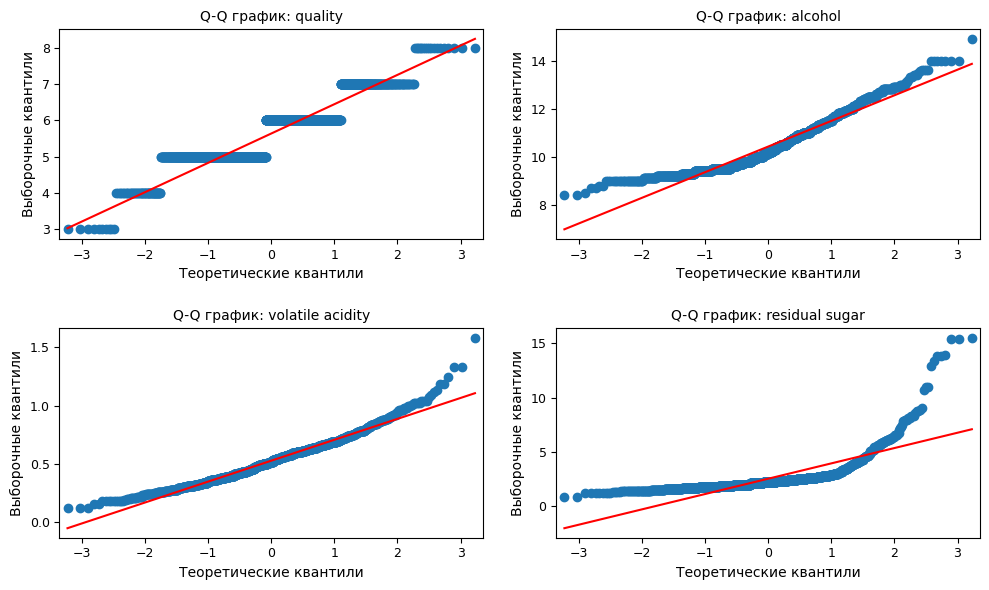

In [27]:
fig = plt.figure(figsize=(10, 6))

ax1 = plt.subplot(221)
sm.qqplot(df['quality'], ax=ax1, line='s')
plt.xticks(fontsize=9)
plt.xlabel('Теоретические квантили', fontsize=10)
plt.yticks(fontsize=9)
plt.ylabel('Выборочные квантили', fontsize=10)
ax1.set_title('Q-Q график: quality', fontsize=10)

ax2 = plt.subplot(222)
sm.qqplot(df['alcohol'], ax=ax2, line='s')
plt.xticks(fontsize=9)
plt.xlabel('Теоретические квантили', fontsize=10)
plt.yticks(fontsize=9)
plt.ylabel('Выборочные квантили', fontsize=10)
ax2.set_title('Q-Q график: alcohol', fontsize=10)

ax3 = plt.subplot(223)
sm.qqplot(df['volatile acidity'], ax=ax3, line='s')
plt.xticks(fontsize=9)
plt.xlabel('Теоретические квантили', fontsize=10)
plt.yticks(fontsize=9)
plt.ylabel('Выборочные квантили', fontsize=10)
ax3.set_title('Q-Q график: volatile acidity', fontsize=10)

ax4 = plt.subplot(224)
sm.qqplot(df['residual sugar'], ax=ax4, line='s')
plt.xticks(fontsize=9)
plt.xlabel('Теоретические квантили', fontsize=10)
plt.yticks(fontsize=9)
plt.ylabel('Выборочные квантили', fontsize=10)
ax4.set_title('Q-Q график: residual sugar', fontsize=10)

fig.tight_layout(h_pad=2, w_pad=2)

plt.show()


### Метод огибающих

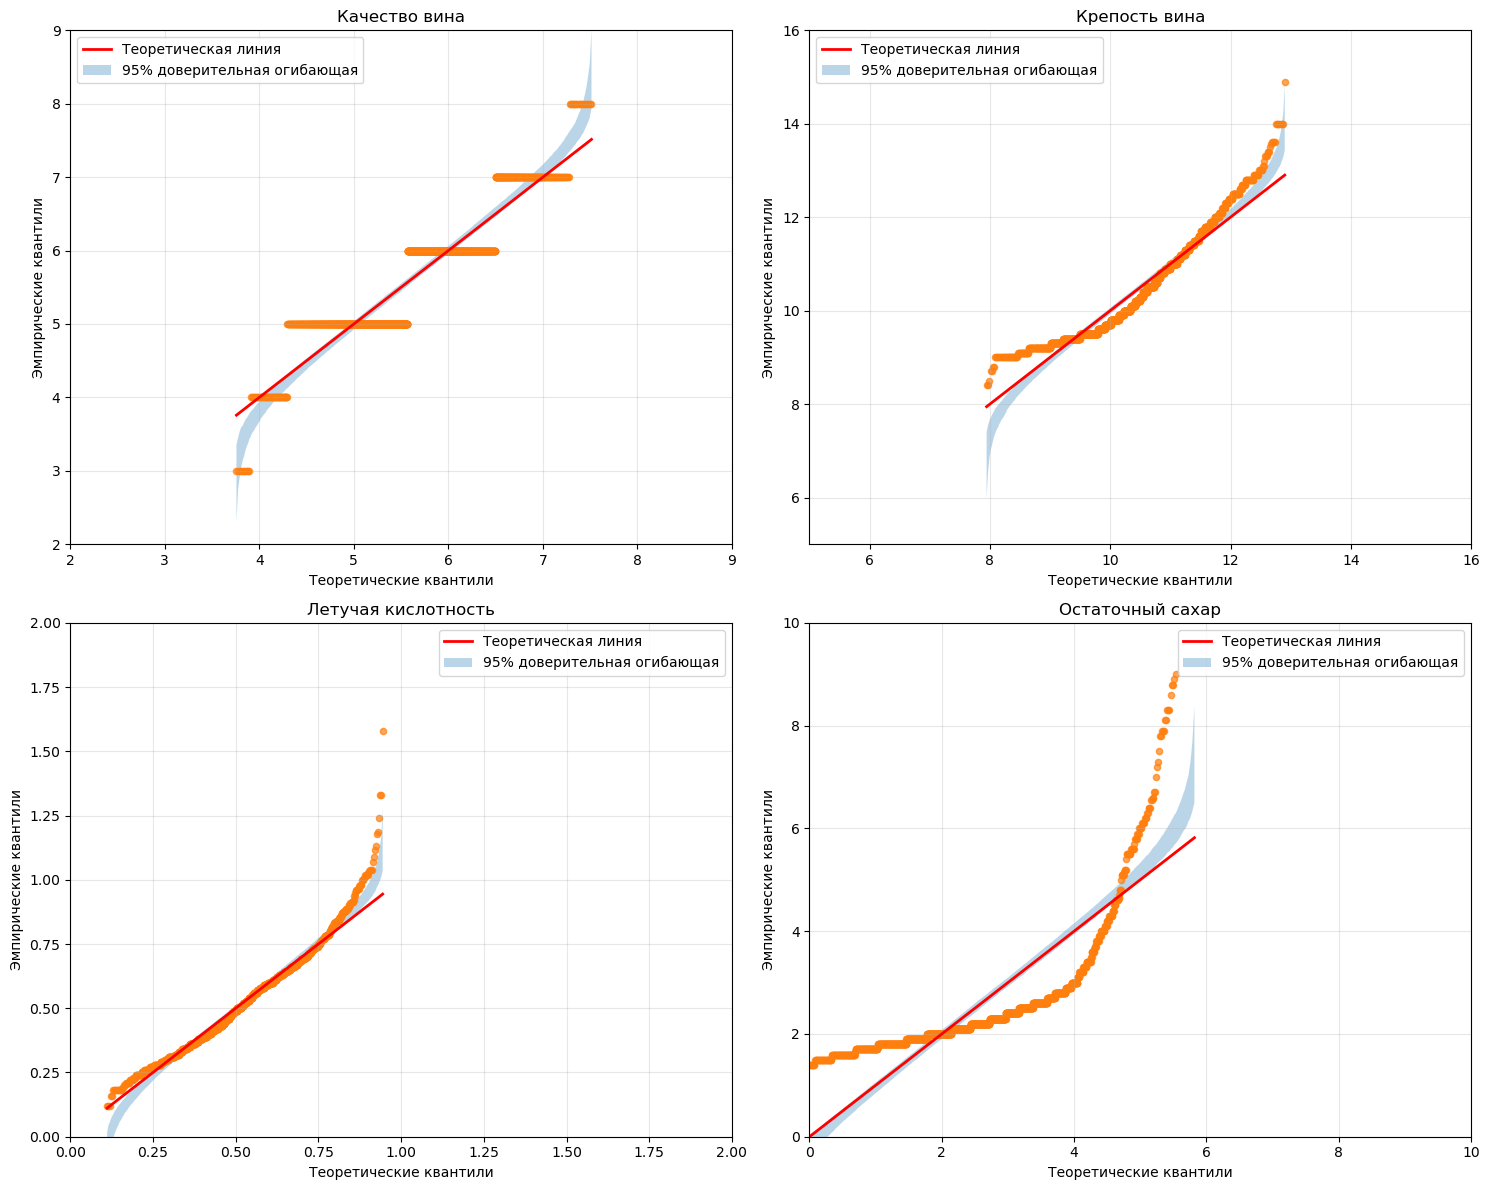

In [28]:
def envelope_method(data, dist='norm', alpha=0.05, n_sim=1000, ax=None, label='', x_limits=None):
    """
    Построение метода огибающей для анализа распределения
    
    Parameters:
    data - массив данных
    dist - тип распределения ('norm' для нормального)
    alpha - уровень значимости
    n_sim - количество симуляций для построения огибающей
    ax - ось для построения графика
    label - метка для данных
    x_limits - кортеж (min, max) для ограничения оси X, либо None для автоматического выбора
    """
    
    # Сортируем данные
    data_sorted = np.sort(data)
    n = len(data_sorted)
    
    # Теоретические квантили
    # Оцениваем параметры нормального распределения
    mu, sigma = np.mean(data), np.std(data)
    theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, n), mu, sigma)
    
    # Генерируем симуляции для построения огибающей
    envelope_data = []
    
    for _ in range(n_sim):
        # Генерируем данные из теоретического распределения
        sim_data = np.random.normal(mu, sigma, n)        
        sim_sorted = np.sort(sim_data)
        envelope_data.append(sim_sorted)
    
    envelope_data = np.array(envelope_data)
    
    # Вычисляем процентили для огибающей
    lower_bound = np.percentile(envelope_data, alpha/2*100, axis=0)
    upper_bound = np.percentile(envelope_data, (1-alpha/2)*100, axis=0)
    
    # Создаем график
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # Теоретическая линия
    ax.plot(theoretical_quantiles, theoretical_quantiles, 'r-', linewidth=2, label='Теоретическая линия')
    
    # Огибающая
    ax.fill_between(theoretical_quantiles, lower_bound, upper_bound, alpha=0.3,label=f'{int((1-alpha)*100)}% доверительная огибающая')
    
    # Эмпирические данные
    ax.scatter(theoretical_quantiles, data_sorted, alpha=0.7, s=20, label=label)

    # Устанавливаем пределы осей
    if x_limits is not None:
        ax.set_xlim(x_limits[0], x_limits[1])
        ax.set_ylim(x_limits[0], x_limits[1])
    else:
        ax.set_xlim(-6, 6)
        ax.set_ylim(-6, 6)
    
    plt.xticks(fontsize=10)
    ax.set_xlabel('Теоретические квантили')
    plt.yticks(fontsize=10)
    ax.set_ylabel('Эмпирические квантили')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return ax

# Создаем subplots для сравнения
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Анализируем каждый набор данных с индивидуальными пределами оси X
envelope_method(df['quality'], ax=axes[0,0], x_limits=(2, 9))
axes[0,0].set_title('Качество вина')

envelope_method(df['alcohol'], ax=axes[0,1], x_limits=(5, 16))
axes[0,1].set_title('Крепость вина')

envelope_method(df['volatile acidity'], ax=axes[1,0], x_limits=(0, 2))
axes[1,0].set_title('Летучая кислотность')

envelope_method(df['residual sugar'], ax=axes[1,1], x_limits=(0, 10))
axes[1,1].set_title('Остаточный сахар')

plt.tight_layout()
plt.show()

### Критерии Колмогорова-Смирнова, Шапиро-Уилка, Андерсона-Дарлинга, Крамера фон Мизеса, Колмогорова-Смирнова в модификации Лиллиефорса и Шапиро-Франсия

In [29]:
Data = [df['quality'], df['alcohol'], df['volatile acidity'],df['residual sugar'] ]
Names = ['Качество вина', 'Крепость вина', 'Летучая кислотность', 'Остаточный сахар']

In [30]:
print('\nСмирнов-Колмогоров')
for i in range(len(Data)):
  _, p_value = kstest(Data[i], 'norm', args=(np.mean(Data[i]), np.std(Data[i])))
  printresults(p_value, Names[i])

print('\nШапиро-Уилк')
for i in range(len(Data)):
  _, p_value = shapiro(Data[i])
  printresults(p_value, Names[i])

print('\nАндерсон-Дарлинг')
for i in range(len(Data)):
    result = anderson(Data[i], dist='norm')
    statistic = result.statistic
    critical_value_5_percent = result.critical_values[2]  # Критическое значение для уровня значимости 5%
    p_value = 0.04 if statistic > critical_value_5_percent else 0.06
    printresults(p_value, Names[i])

print('\nКрамер-фон Мизес')
for i in range(len(Data)):
    result = cramervonmises(Data[i], 'norm', args=(np.mean(Data[i]), np.std(Data[i])))
    p_value = result.pvalue
    printresults(p_value, Names[i])

print('\nЛиллиефорс')
for i in range(len(Data)):
    _, p_value = lilliefors(Data[i], dist='norm')
    printresults(p_value, Names[i])

print('\nШапиро-Франсия')
for i in range(len(Data)):
    _, p_value = shapiro(Data[i])
    printresults(p_value, Names[i])


Смирнов-Колмогоров
Качество вина
    pvalue = 1.8436724605657562e-88
    Есть ли основания отбросить гипотезу? Да
Крепость вина
    pvalue = 4.9913769120144675e-21
    Есть ли основания отбросить гипотезу? Да
Летучая кислотность
    pvalue = 0.00013308448101431212
    Есть ли основания отбросить гипотезу? Да
Остаточный сахар
    pvalue = 2.4273158016535143e-96
    Есть ли основания отбросить гипотезу? Да

Шапиро-Уилк
Качество вина
    pvalue = 9.515084999430088e-36
    Есть ли основания отбросить гипотезу? Да
Крепость вина
    pvalue = 6.644056905730039e-27
    Есть ли основания отбросить гипотезу? Да
Летучая кислотность
    pvalue = 2.692934735712727e-16
    Есть ли основания отбросить гипотезу? Да
Остаточный сахар
    pvalue = 1.0201616453237868e-52
    Есть ли основания отбросить гипотезу? Да

Андерсон-Дарлинг
Качество вина
    pvalue = 0.04
    Есть ли основания отбросить гипотезу? Да
Крепость вина
    pvalue = 0.04
    Есть ли основания отбросить гипотезу? Да
Летучая кислотность


<h4>Выводы:</h4> 

<p>Как видно, почти все распределения , кроме качества вина, похожи на нормальное, однако очевидно, что критерии отвергли все распределения, так как они не являются нормальными.</p>